In [30]:
data(morley)
library(dplyr)
library(ggplot2)

In [32]:
morley_wide <- reshape(morley,
                       timevar = "Run",
                       idvar = "Expt",
                       direction = "wide")

In [33]:
morley_wide %>%
  rowwise() %>%
  mutate(
    media = mean(c_across(starts_with("Speed"))),
    dp    = sd(c_across(starts_with("Speed"))),
    min = min(c_across(starts_with("Speed"))),
    max    = max(c_across(starts_with("Speed")))
  ) %>%
  select(Expt, media, dp,min,max)

Expt,media,dp,min,max
<int>,<dbl>,<dbl>,<int>,<int>
1,909.0,104.92604,650,1070
2,856.0,61.16414,760,960
3,845.0,79.10686,620,970
4,820.5,60.04165,720,920
5,831.5,54.21934,740,950


In [35]:
library(dplyr)

morley %>%
  group_by(Expt) %>%
  summarise(
    W = shapiro.test(Speed)$statistic,
    p_valor = shapiro.test(Speed)$p.value
  )

Expt,W,p_valor
<int>,<dbl>,<dbl>
1,0.9199248,0.098755612
2,0.9317972,0.167208431
3,0.8368485,0.003234519
4,0.9611299,0.566662969
5,0.9351800,0.194142597


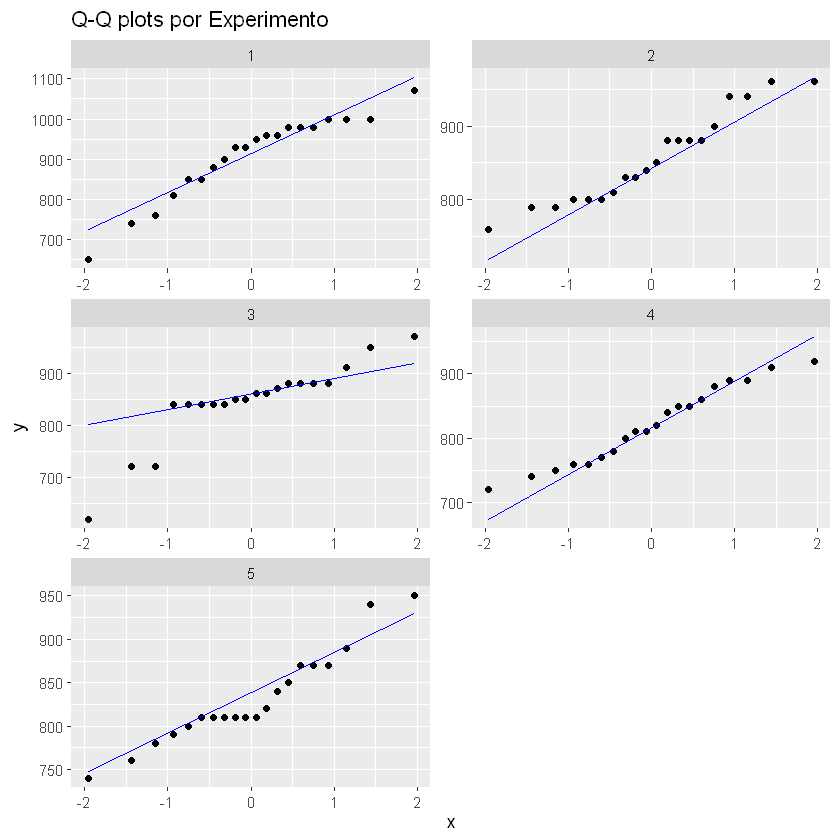

In [26]:
# Com ggplot2 (recomendado, pois facetas facilitam a comparação)
library(ggplot2)

ggplot(morley, aes(sample = Speed)) +
  stat_qq() +
  stat_qq_line(col = "blue") +
  facet_wrap(~ Expt, scales = "free", ncol = 2) +
  labs(title = "Q-Q plots por Experimento")

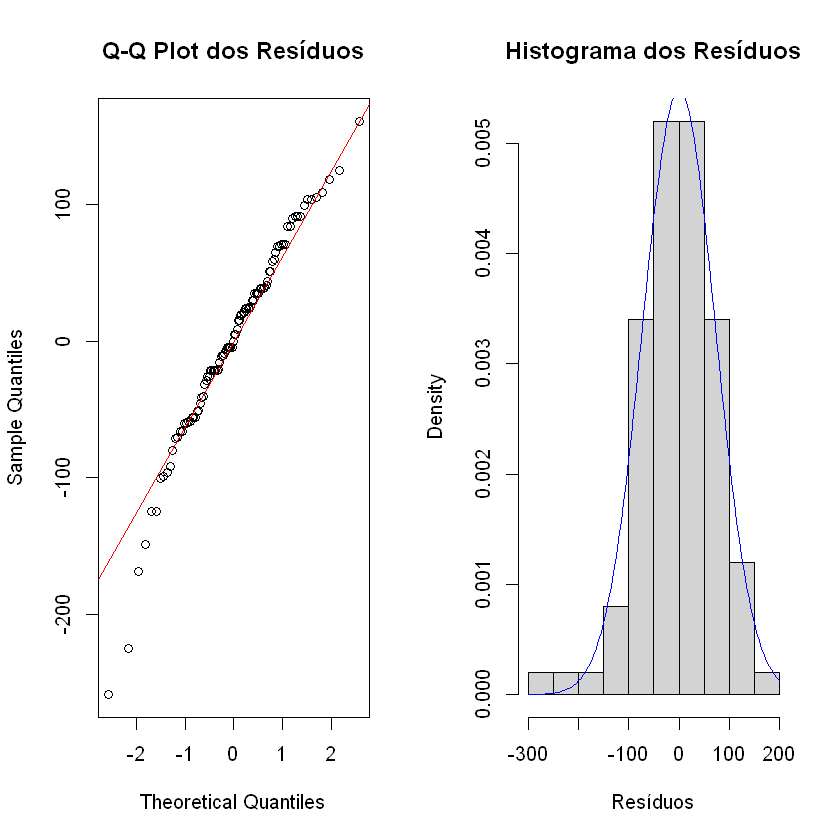

In [16]:
modelo <- aov(Speed ~ Expt, data = morley)
# a) Q-Q plot dos resíduos
par(mfrow = c(1,2))
qqnorm(residuals(modelo), main = "Q-Q Plot dos Resíduos")
qqline(residuals(modelo), col = "red")

# b) Histograma com curva normal teórica
hist(residuals(modelo), breaks = 10, probability = TRUE, 
     main = "Histograma dos Resíduos", xlab = "Resíduos")
curve(dnorm(x, mean = mean(residuals(modelo)), sd = sd(residuals(modelo))), 
      add = TRUE, col = "blue")

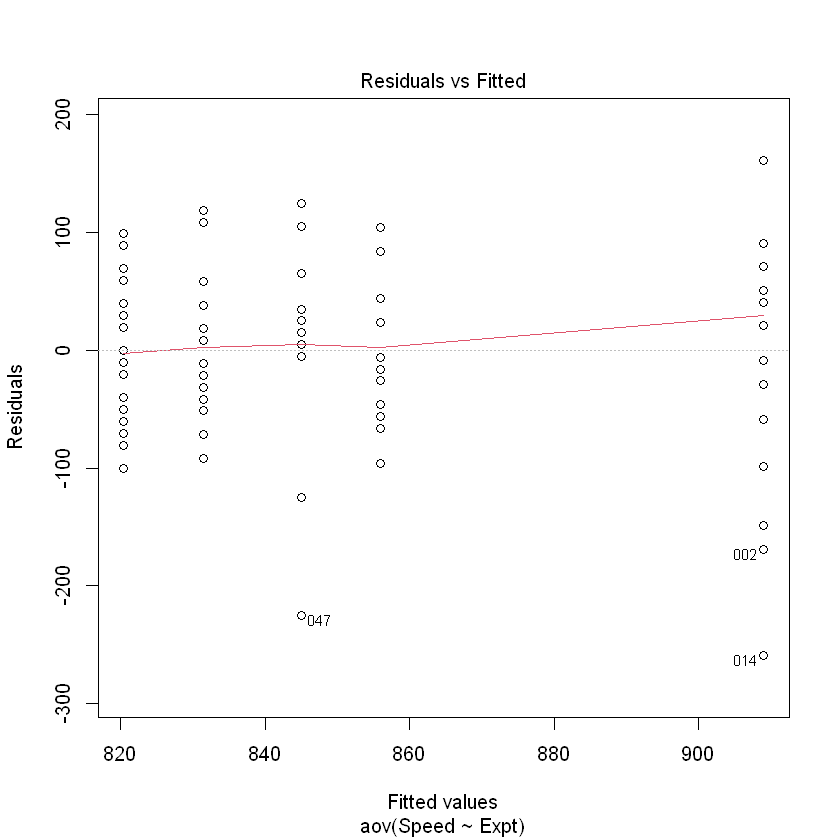

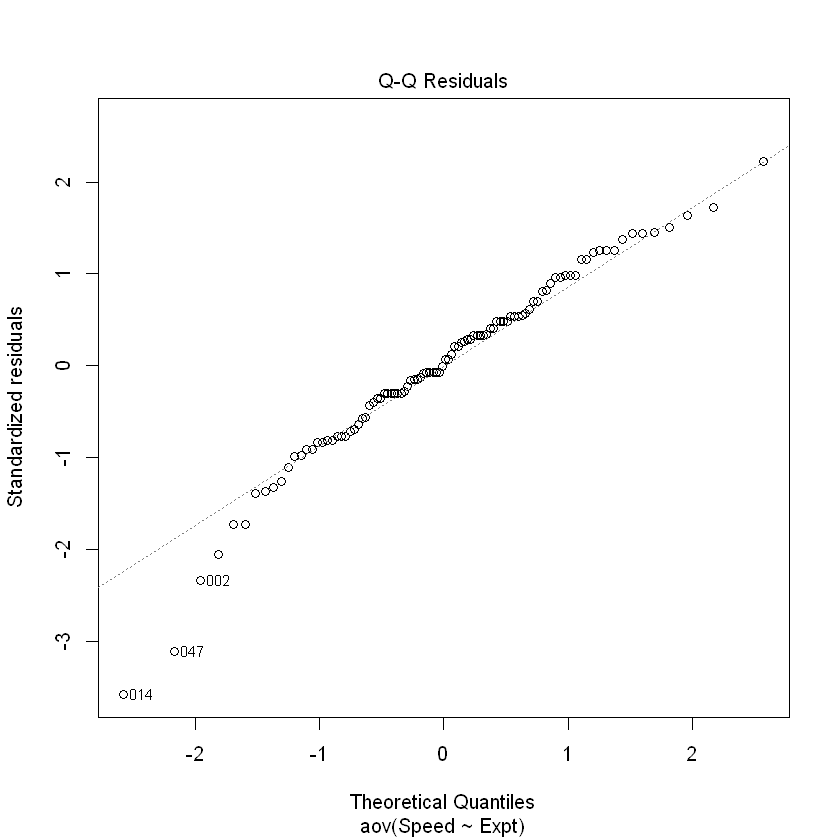

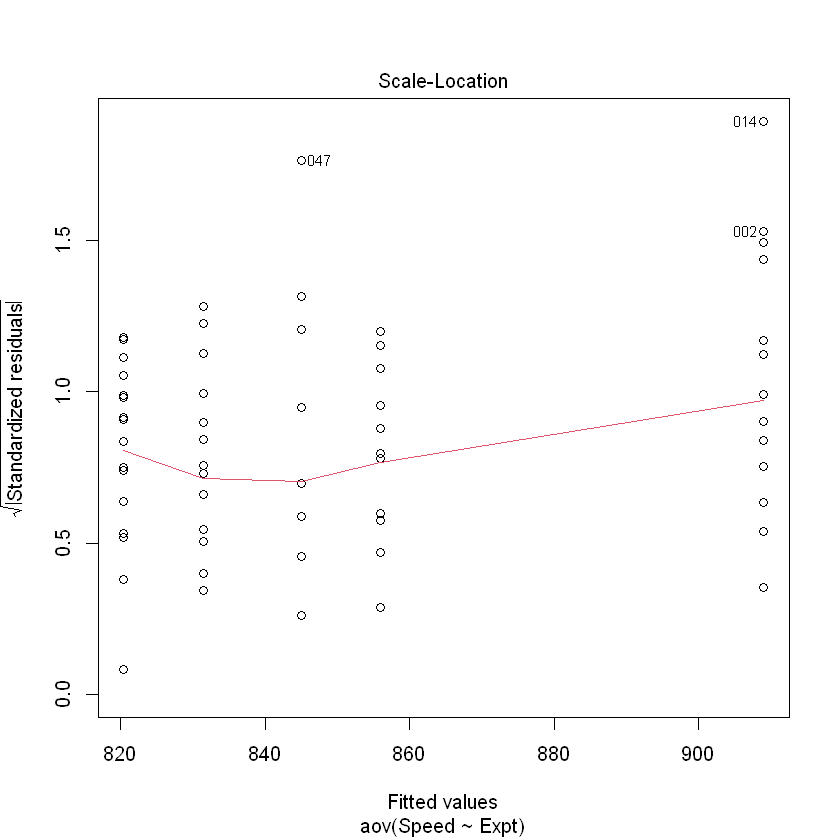

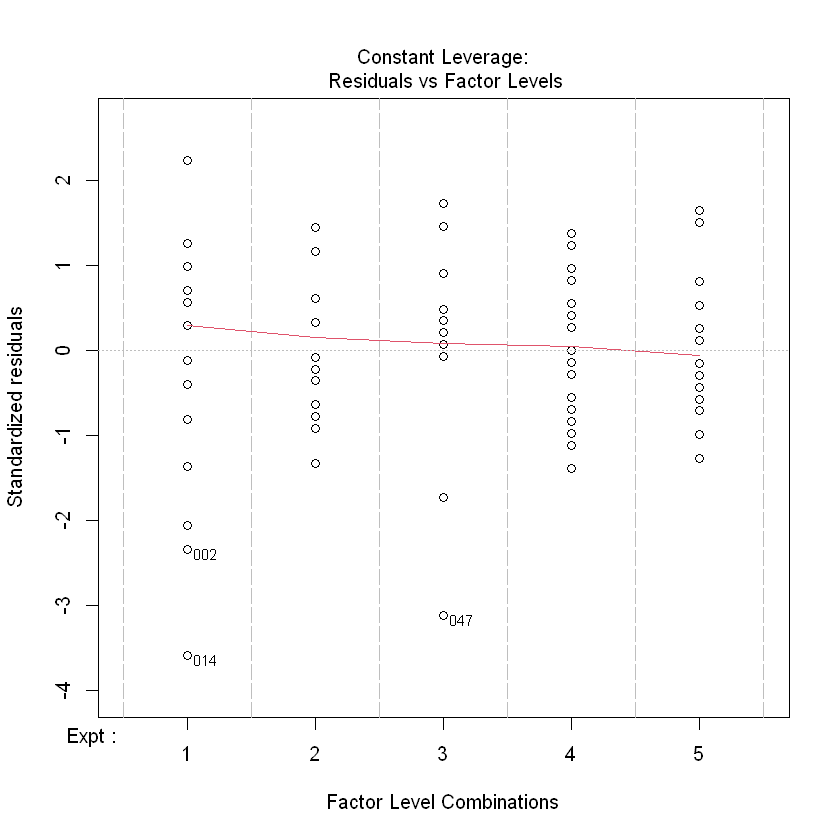

In [38]:
plot(modelo)

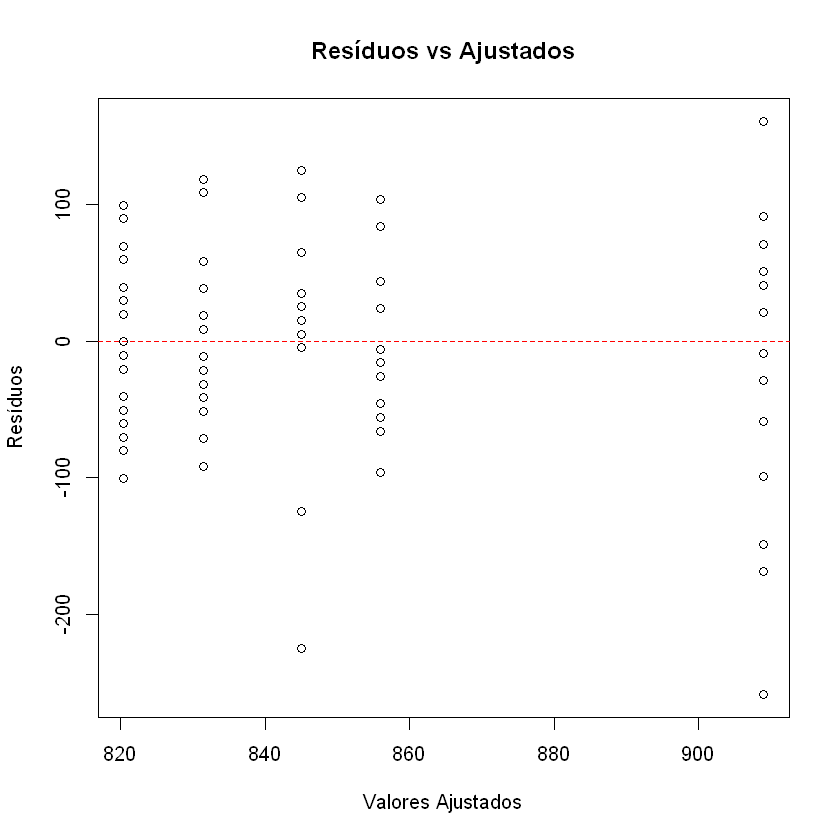

In [37]:
# a) Resíduos vs valores ajustados (não deve apresentar padrão)
plot(fitted(modelo), residuals(modelo), 
     xlab = "Valores Ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados")
abline(h = 0, col = "red", lty = 2)

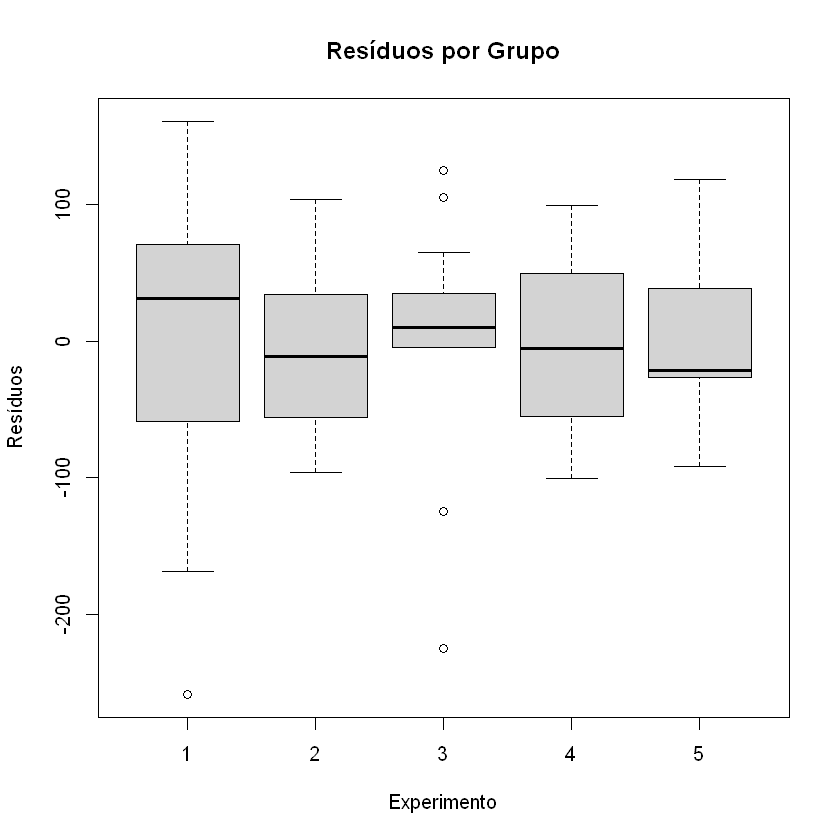

In [18]:
# b) Boxplot dos resíduos por grupo (Expt)
boxplot(residuals(modelo) ~ Expt, data = morley,
        xlab = "Experimento", ylab = "Resíduos",
        main = "Resíduos por Grupo")

In [2]:
morley$Expt <- as.factor(morley$Expt)

model_morley <- aov(Speed ~ Expt, data = morley)
summary(model_morley)

            Df Sum Sq Mean Sq F value  Pr(>F)   
Expt         4  94514   23629   4.288 0.00311 **
Residuals   95 523510    5511                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1